# Remove the outliers of features
by using a centered (!) moving median

In [1]:
from config.intervals import SEGMENT
import math
from typing import Literal
import numpy as np
from functools import partial
import pandas as pd
from pandas import Timedelta, DataFrame
from config import PATHS
from feature_extraction.extract_features import FeatureNames
import matplotlib.pyplot as plt
from cycle_extraction.remove_feature_outliers import rolling_average


In [28]:
rolling_average_seg = partial(rolling_average, sampling_period=SEGMENT.exact_dur)

pdir = PATHS.patient_dirs()[1]
print(pdir.name)
segs_full = pd.read_pickle(pdir.segments_table.pickle).drop(columns=['lead_szr', 'type', 'exists', 'start_index'])
feat_names = FeatureNames.CYCLES
segs = segs_full[['start_mtz', *feat_names]]
segs.head(10)

competition-1


,start_mtz,acfw_D,acfw_P,var_D,var_P
0,2020-11-04 14:26:59.000000,NaN,NaN,NaN,NaN
1,2020-11-04 14:27:13.997750,NaN,NaN,NaN,NaN
2,2020-11-04 14:27:28.995500,NaN,NaN,NaN,NaN
3,2020-11-04 14:27:43.993250,NaN,NaN,NaN,NaN
4,2020-11-04 14:27:58.991000,NaN,NaN,NaN,NaN
5,2020-11-04 14:28:13.988750,9.0,10.0,114.154016,201.381958
6,2020-11-04 14:28:28.986500,21.0,10.0,78.619963,86.045538
7,2020-11-04 14:28:43.984250,2.0,1.0,19.308111,42.918956
8,2020-11-04 14:28:58.982000,1.0,1.0,15.731357,44.277487
9,2020-11-04 14:29:13.979750,2.0,1.0,14.885805,39.481537


In [3]:
def plot_features(
        df,
        x_col="start_mtz",  # set to None to use df.index
        figsize_per_row=2.0,
        lw=0.8,
        color="tab:blue",
):
    x = df[x_col] if x_col is not None else df.index
    n = len(feat_names)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        sharex=True,
        figsize=(14, max(2, figsize_per_row * n)),
        constrained_layout=True,
    )

    # Make sure axes is iterable when n == 1
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, feat_names):
        y = df[col].to_numpy(dtype=float)  # NaN -> gaps in line
        ax.plot(x, y, lw=lw, color=color)
        ax.set_ylabel(col)
        ax.set_title(col, loc="left", fontsize=10)
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel(x_col if x_col is not None else "index")
    return fig

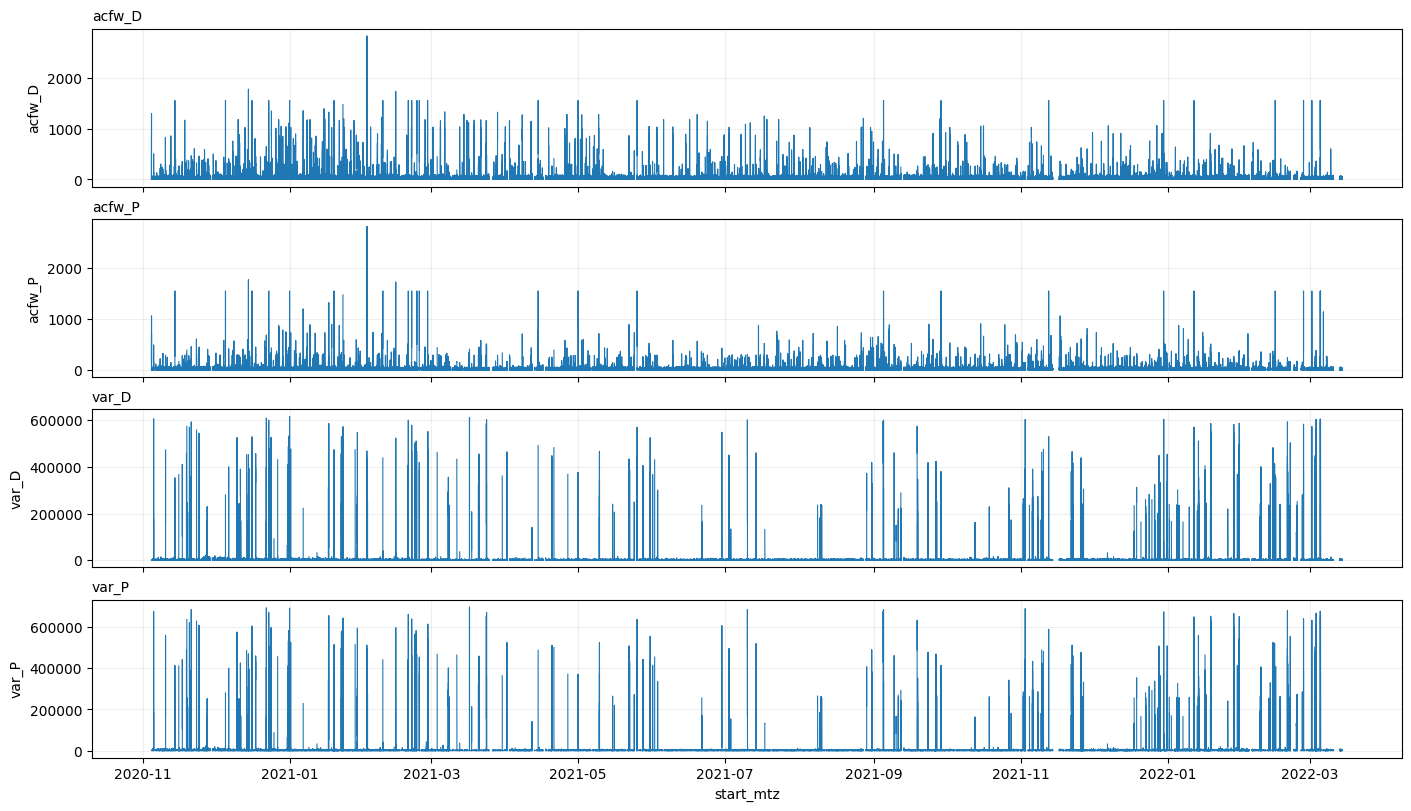

In [4]:
# Raw Features
plot_features(segs).show()

In [5]:
segs_above_thresh = segs[segs['var_P'] > 400000]
print(len(segs_above_thresh['var_P']) / len(segs) * 100, "% of segments above threshold")

0.009364954376537808 % of segments above threshold


In [6]:
segs_below_thresh = segs[segs['var_P'] < 20000]
# plot_features(segs_below_thresh).show()

min_periods=0


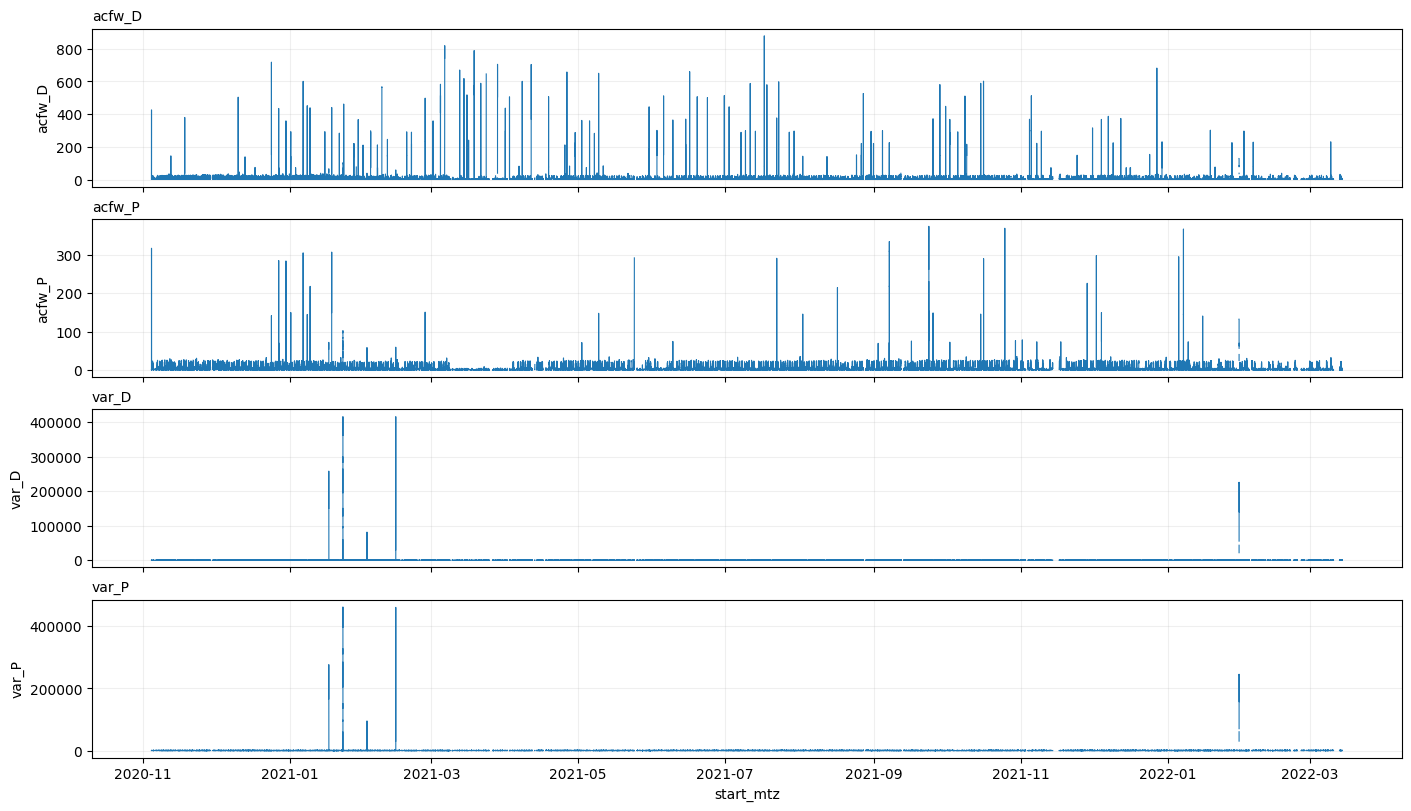

In [22]:
# todo adjust window length to multiple of segment length
segs_averaged = rolling_average_seg(segs, window=Timedelta(minutes=10), min_valid_duration=Timedelta(minutes=0), agg='median')
plot_features(segs_averaged).show()

In [29]:
extreme_segs = segs_full[segs_averaged['var_P'] > 20000]
print(f"From {extreme_segs['start_mtz'].min()} to {extreme_segs['start_mtz'].max()}")
extreme_segs

From 2021-01-17 07:39:48.481250 to 2022-01-30 16:16:04.219250


,start_mtz,file,corrcoef,acfw_D,acfw_P,var_D,var_P,Delta_D,Theta_D,Alpha_D,Beta_D,Gamma_D,Delta_P,Theta_P,Alpha_P,Beta_P,Gamma_P
424675,2021-01-17 07:39:48.481250,competition-1_0320_2021-01-17_05-08-42.edf,0.980818,40.0,42.0,54678.589460,54653.233148,29583.399930,6059.570888,1867.983012,1390.320379,802.842508,29417.215668,5990.723200,1840.872276,1384.793896,805.491998
424676,2021-01-17 07:40:03.479000,competition-1_0320_2021-01-17_05-08-42.edf,0.999808,56.0,56.0,97785.228873,97896.458782,30723.707557,3246.232504,572.026607,1286.946491,538.958106,30960.175788,3222.945711,565.129927,1289.129248,537.197665
424677,2021-01-17 07:40:18.476750,competition-1_0320_2021-01-17_05-08-42.edf,0.998988,12.0,12.0,58987.742188,58983.751295,26207.634066,5954.323468,1159.392946,2248.454849,1019.303636,26152.332534,5949.244285,1140.596352,2182.116203,976.871059
424678,2021-01-17 07:40:33.474500,competition-1_0320_2021-01-17_05-08-42.edf,0.999139,802.0,802.0,28775.755085,28812.812645,11570.064558,3123.775793,315.032848,1076.985925,435.484160,11629.229287,3129.871805,310.293842,1087.177228,436.442592
424679,2021-01-17 07:40:48.472250,competition-1_0320_2021-01-17_05-08-42.edf,0.999054,21.0,21.0,76917.700063,77116.379123,40111.424711,4976.590873,1122.341338,1877.420947,827.506048,40068.274821,4970.511137,1117.355197,1895.310917,831.361955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2604336,2022-01-30 16:13:19.244000,competition-1_1753_2022-01-30_15-56-53.edf,-0.582092,3.0,6.0,10.041352,37.542732,3.190135,1.258821,1.841428,2.779111,0.741706,15.182614,2.086907,3.161861,8.448085,3.089434
2604337,2022-01-30 16:13:34.241750,competition-1_1753_2022-01-30_15-56-53.edf,0.998057,316.0,302.0,420229.378091,438289.393084,27499.463070,1461.983121,480.701765,1975.705664,930.429196,30164.223100,1602.238327,532.423308,2043.502593,886.271213
2604340,2022-01-30 16:14:19.235000,competition-1_1753_2022-01-30_15-56-53.edf,0.989787,106.0,132.0,55408.502644,70304.574625,6115.070674,1153.062394,471.680485,465.792246,261.325075,7127.078473,1329.550374,553.504406,539.467418,317.880391
2604343,2022-01-30 16:15:04.228250,competition-1_1753_2022-01-30_15-56-53.edf,-0.534543,3.0,2.0,10.641745,42.517187,2.617400,1.764991,1.487749,2.541757,0.556766,5.381110,2.959640,5.953692,14.807916,6.375095


In [43]:
first_extreme_idx = extreme_segs.index[0]
segs_full.loc[range(first_extreme_idx - 40, first_extreme_idx + 100)]

,start_mtz,file,corrcoef,acfw_D,acfw_P,var_D,var_P,Delta_D,Theta_D,Alpha_D,Beta_D,Gamma_D,Delta_P,Theta_P,Alpha_P,Beta_P,Gamma_P
424635,2021-01-17 07:29:48.571250,competition-1_0320_2021-01-17_05-08-42.edf,-0.055519,9.0,5.0,16.450605,16.212461,5.843709,2.655207,1.336504,1.927236,0.437243,3.938118,5.586574,1.541982,2.462536,0.553937
424636,2021-01-17 07:30:03.569000,competition-1_0320_2021-01-17_05-08-42.edf,-0.417979,6.0,6.0,13.126816,15.752536,4.729951,3.896734,1.106901,1.585932,0.463620,5.906032,4.701392,1.450594,2.168713,0.488460
424637,2021-01-17 07:30:18.566750,competition-1_0320_2021-01-17_05-08-42.edf,-0.279812,7.0,6.0,12.662995,14.135219,4.922978,1.971124,1.042107,1.653860,0.461542,6.431197,2.788491,0.960861,2.204808,0.481609
424638,2021-01-17 07:30:33.564500,competition-1_0320_2021-01-17_05-08-42.edf,-0.262074,6.0,3.0,7.733185,7.909492,3.174281,1.214426,0.573531,1.413201,0.469045,1.904629,1.431168,1.043866,1.741036,0.563353
424639,2021-01-17 07:30:48.562250,competition-1_0320_2021-01-17_05-08-42.edf,-0.449931,6.0,4.0,8.962627,9.525073,4.339071,1.586443,0.829743,1.430183,0.493468,3.416450,2.540691,0.998503,1.791315,0.457877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424770,2021-01-17 08:03:33.267500,competition-1_0320_2021-01-17_05-08-42.edf,-0.736313,4.0,4.0,15.129302,22.717671,5.449158,2.696617,3.108417,3.176702,0.464666,6.596927,3.324538,6.465931,5.966121,0.608742
424771,2021-01-17 08:03:48.265250,competition-1_0320_2021-01-17_05-08-42.edf,-0.783797,3.0,3.0,19.906957,27.640763,5.393933,2.554261,3.275440,7.097224,0.466059,7.178952,4.120603,5.965574,9.098164,0.561723
424772,2021-01-17 08:04:03.263000,competition-1_0320_2021-01-17_05-08-42.edf,-0.843094,5.0,5.0,28.090549,49.899823,8.556562,3.895304,2.323544,6.788229,0.387345,12.518186,6.110782,4.472950,10.915286,0.479563
424773,2021-01-17 08:04:18.260750,competition-1_0320_2021-01-17_05-08-42.edf,-0.726558,4.0,4.0,12.702182,20.276708,4.878216,2.180485,1.565148,1.735314,0.503537,7.003883,3.728973,3.409695,2.773295,0.543959


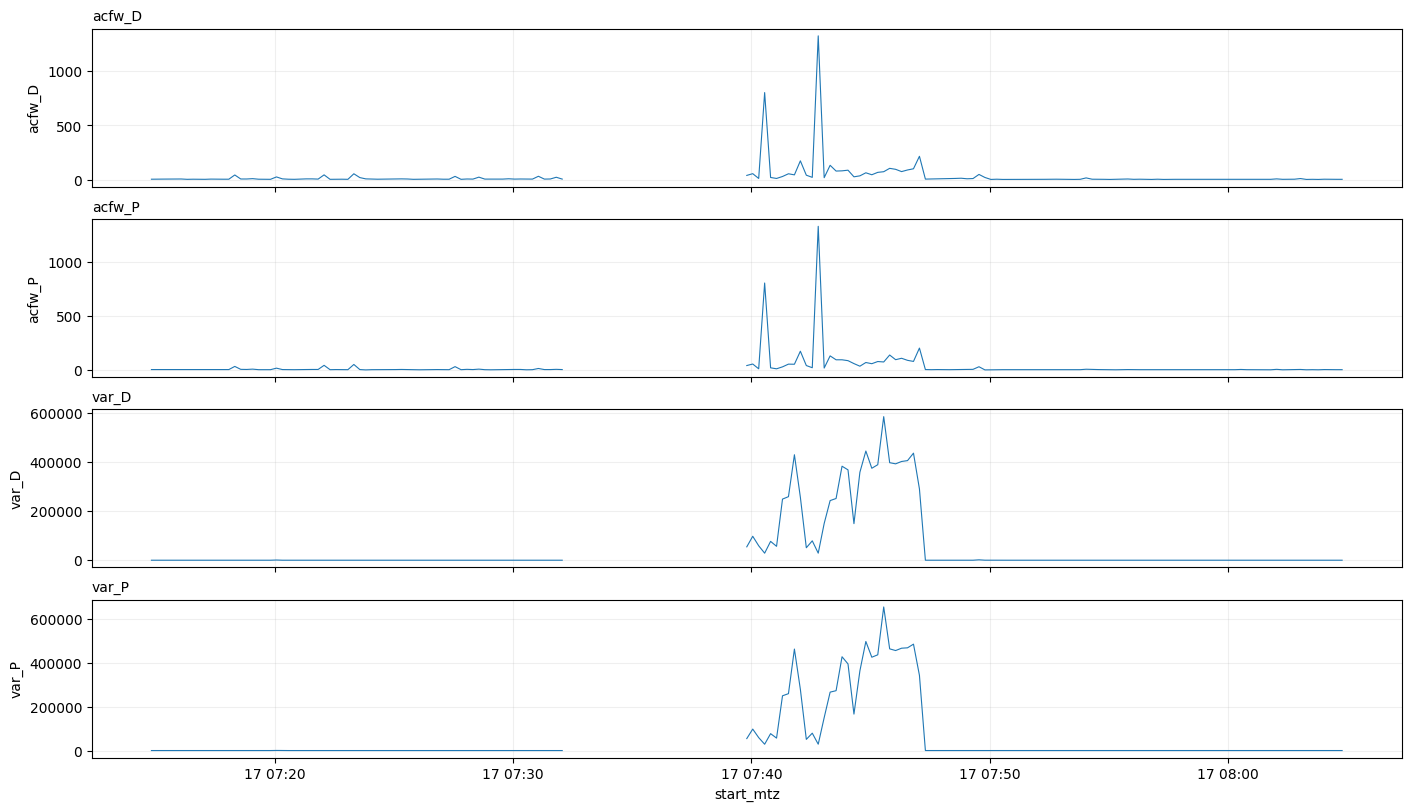

In [35]:
plot_range = (first_extreme_idx - 100, first_extreme_idx + 100)
plot_features(segs.loc[plot_range[0]: plot_range[1]]).show()

In [42]:
file = str(pdir.edf_dir / 'competition-1_0320_2021-01-17_05-08-42.edf')
from pyedflib import highlevel

sigs, sig_headers, headers = highlevel.read_edf(file)

plt.plot(sigs[plot_range[0], plot_range[1]])

IndexError: index 424575 is out of bounds for axis 0 with size 2

In [8]:
print('same length:', len(segs) == len(segs_averaged))
for feat in feat_names:
    same = (segs[feat].isna() == segs_averaged[feat].isna()).all()
    print(f'NA for {feat}: {same}')

same length: True
NA for acfw_D: True
NA for acfw_P: True
NA for var_D: True
NA for var_P: True


min_periods=0


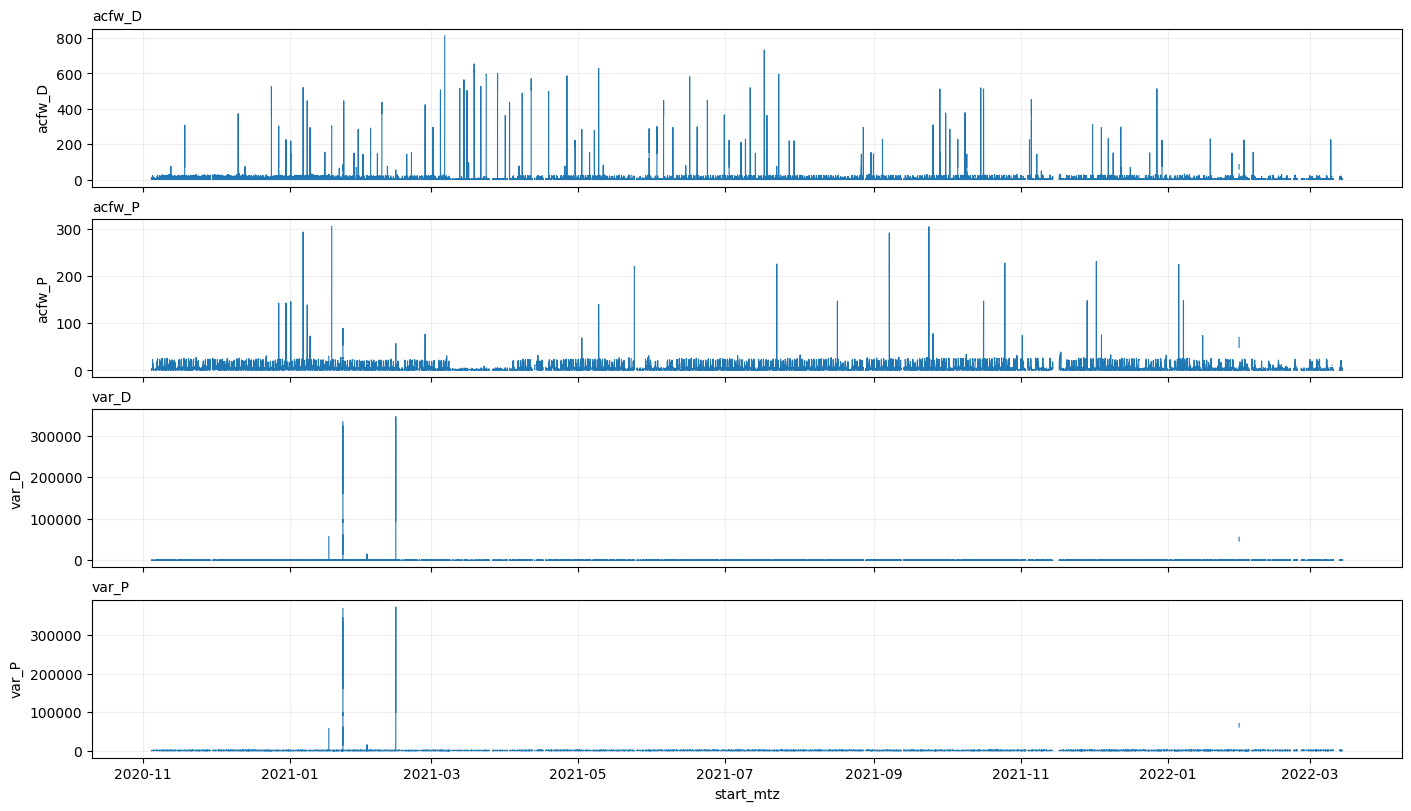

In [14]:
kwargs = {
    'window': Timedelta(minutes=20),
    'min_valid_duration': Timedelta(minutes=0),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=0


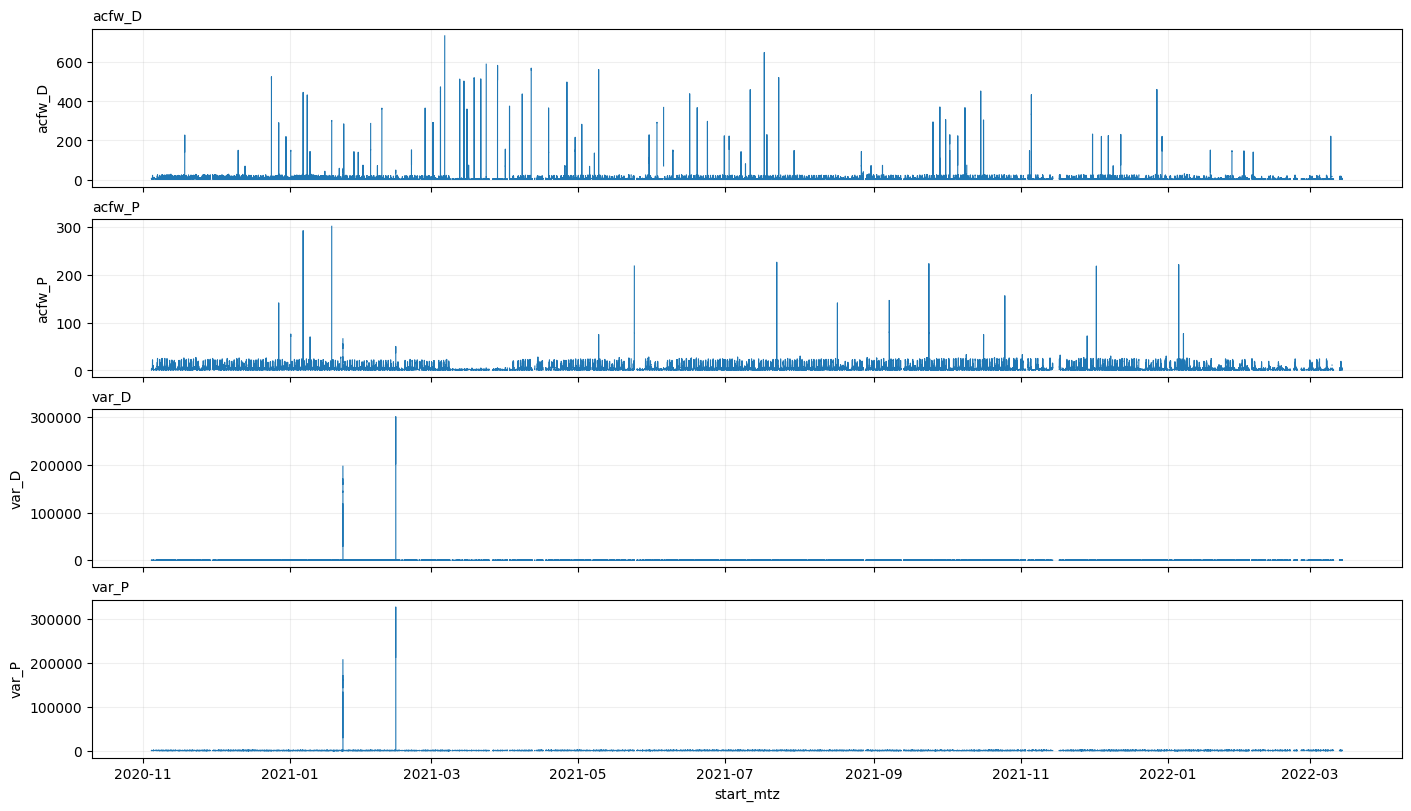

In [15]:
kwargs = {
    'window': Timedelta(minutes=30),
    'min_valid_duration': Timedelta(minutes=0),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=5


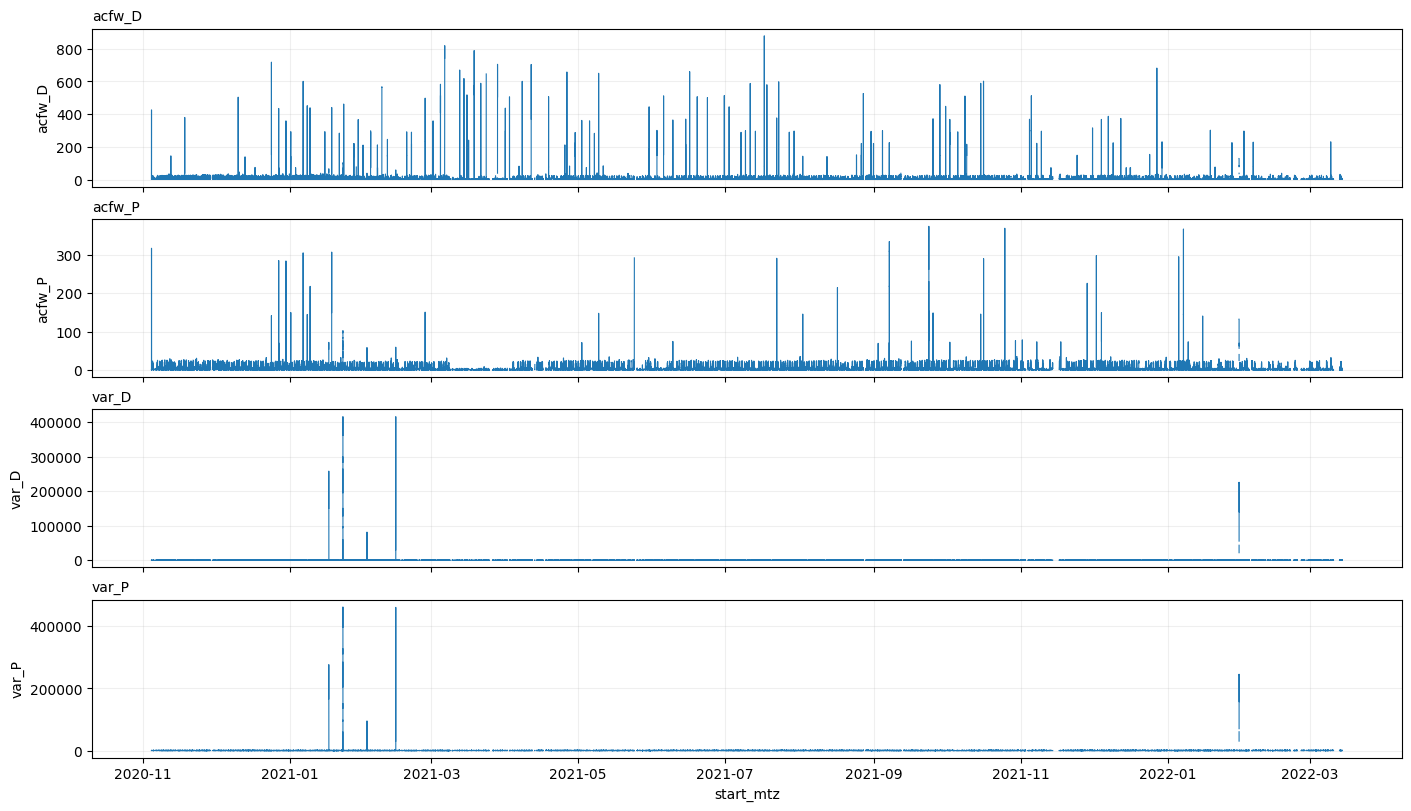

In [16]:
kwargs = {
    'window': Timedelta(minutes=10),
    'min_valid_duration': Timedelta(minutes=1),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=5


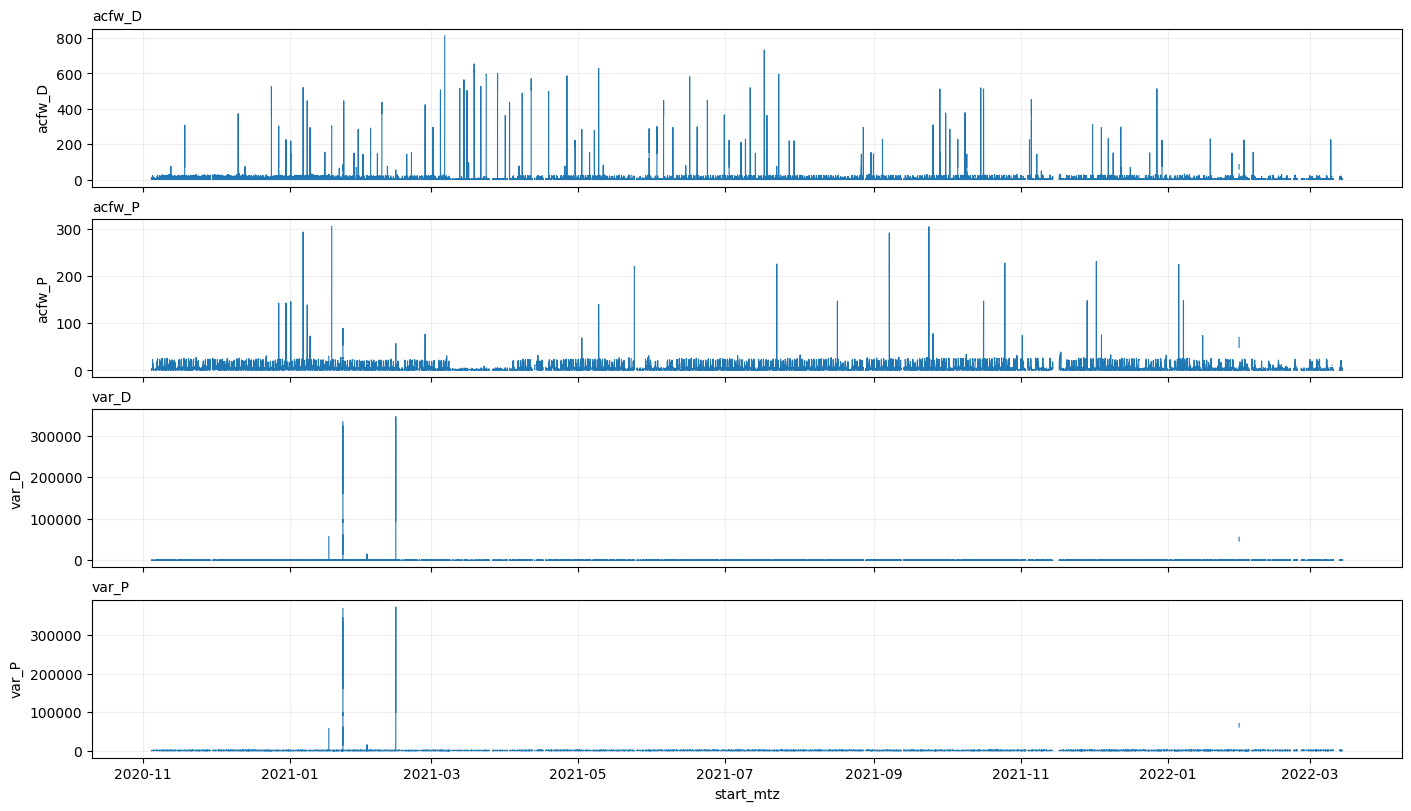

In [17]:
kwargs = {
    'window': Timedelta(minutes=20),
    'min_valid_duration': Timedelta(minutes=1),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=5


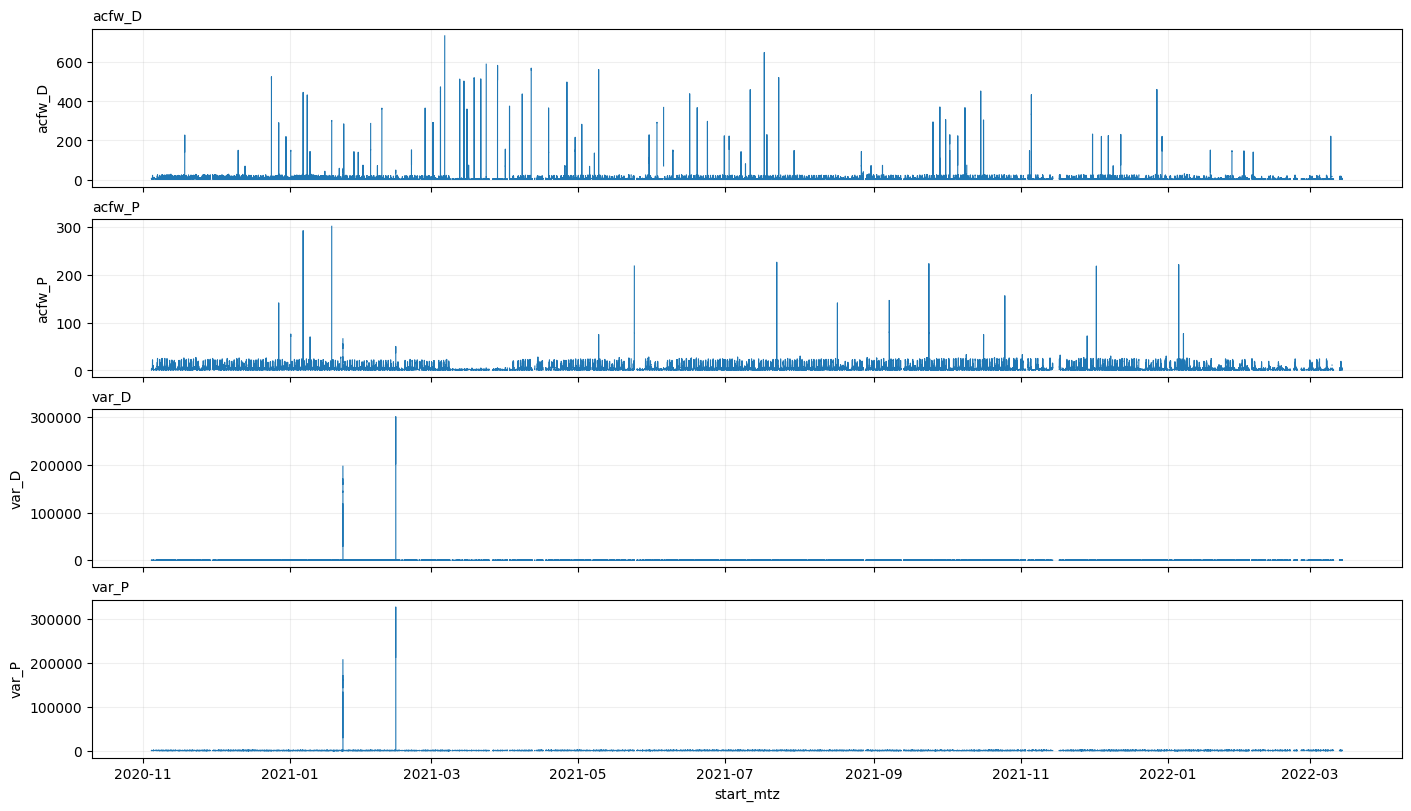

In [18]:
kwargs = {
    'window': Timedelta(minutes=30),
    'min_valid_duration': Timedelta(minutes=1),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=21


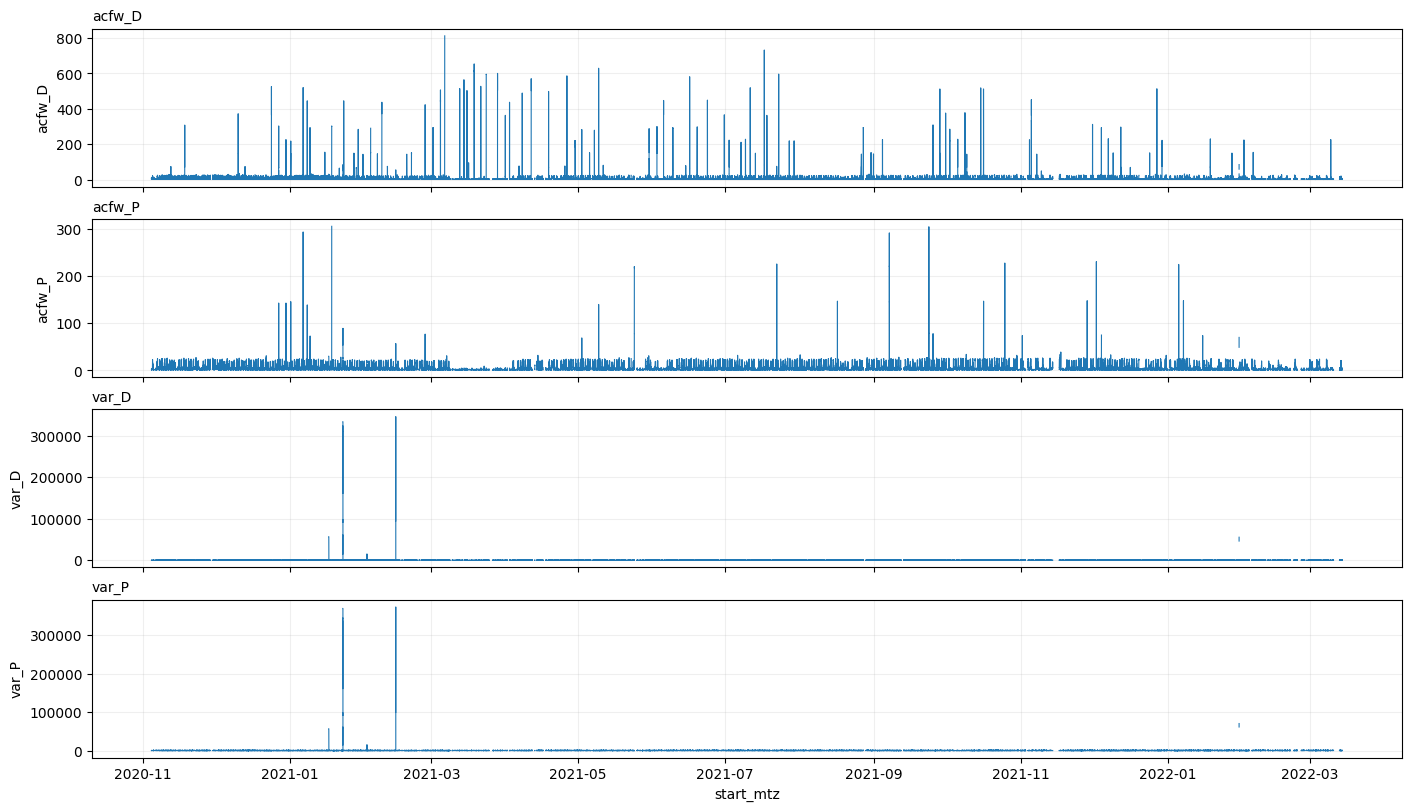

In [19]:
kwargs = {
    'window': Timedelta(minutes=20),
    'min_valid_duration': Timedelta(minutes=5),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=21


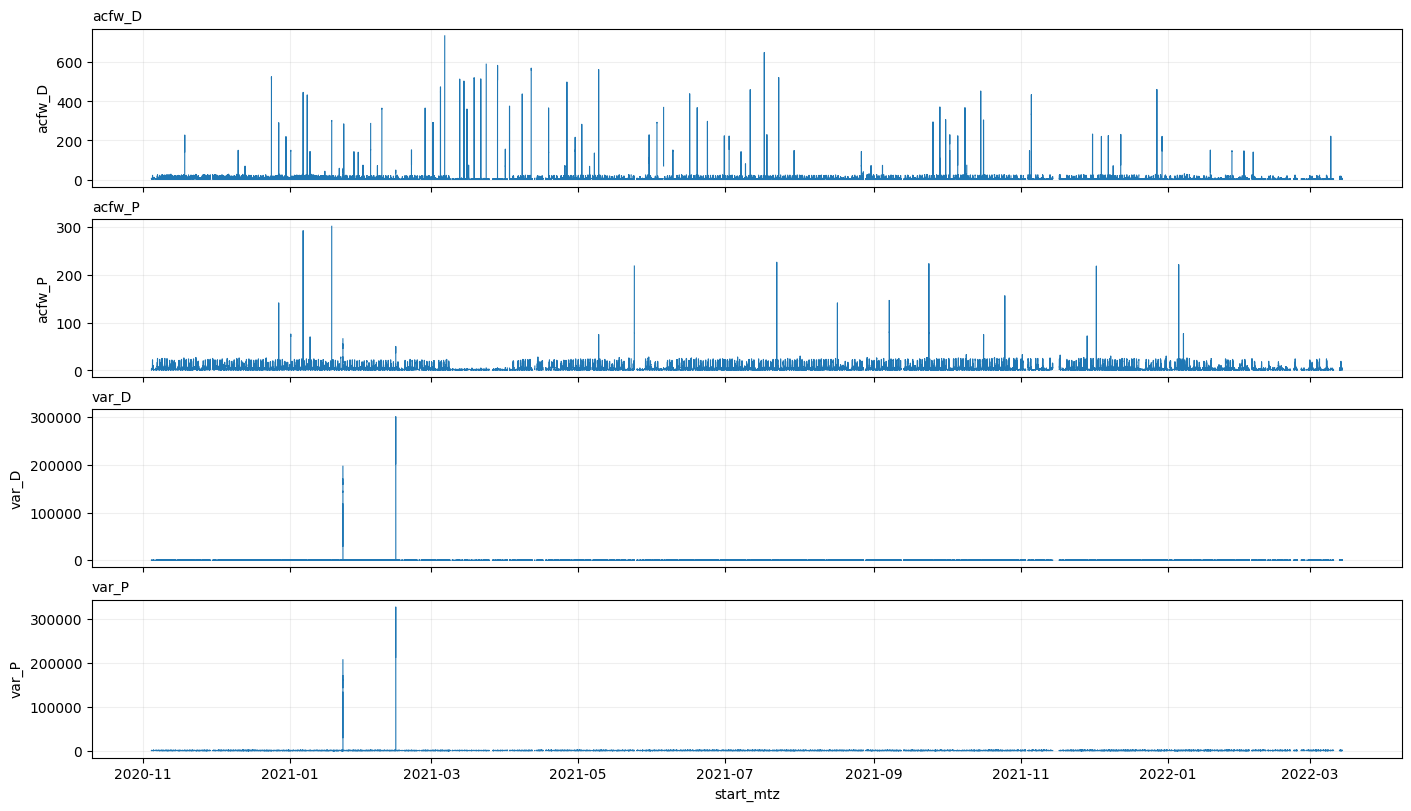

In [20]:
kwargs = {
    'window': Timedelta(minutes=30),
    'min_valid_duration': Timedelta(minutes=5),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

min_periods=41


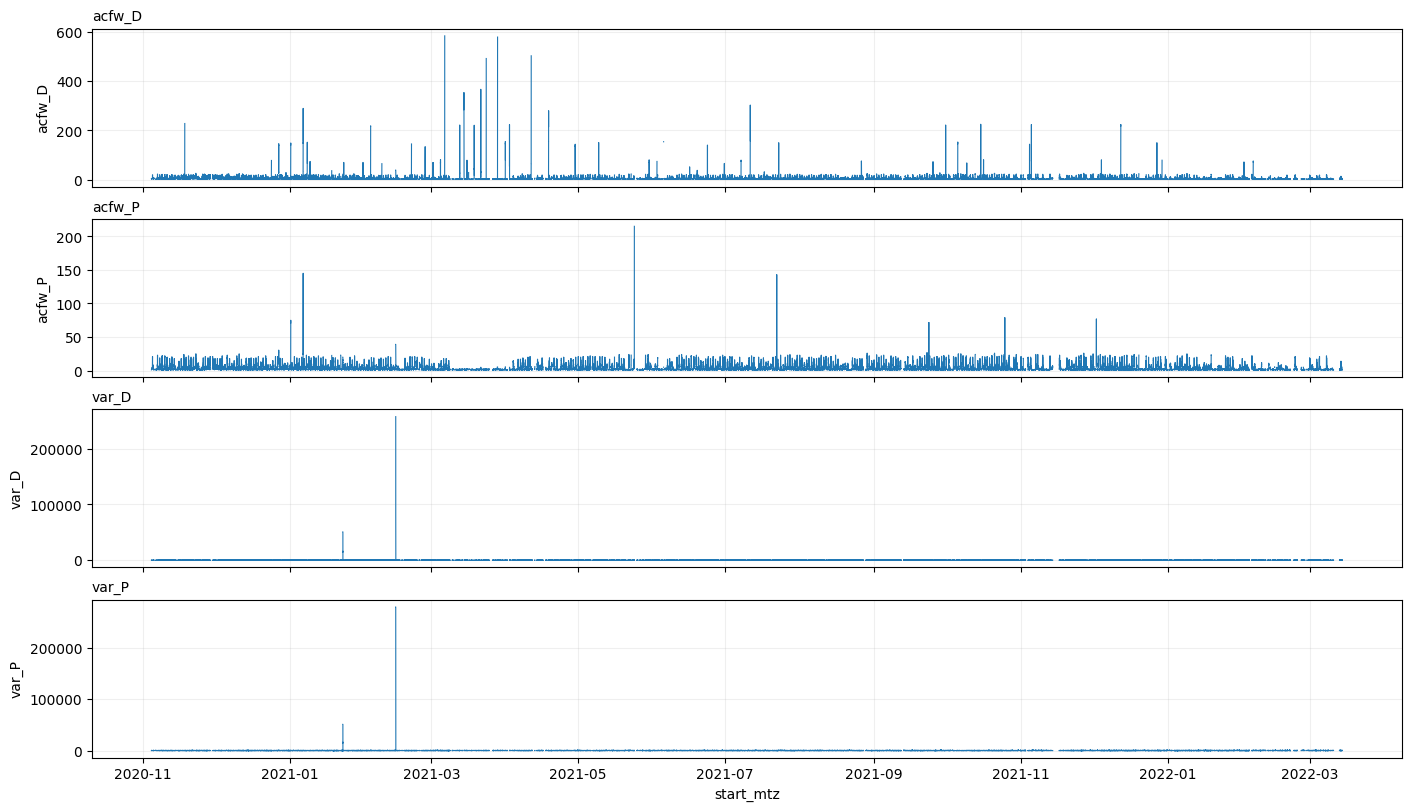

In [21]:
kwargs = {
    'window': Timedelta(minutes=60),
    'min_valid_duration': Timedelta(minutes=10),
    'agg': 'median',
}
plot_features(rolling_average_seg(segs, **kwargs)).show()

# Behavior of min_periods for rolling average

In [18]:
# min_periods for index
s = pd.Series([1.0, np.nan, 3.0, 9.0, np.nan, 5.0, 7.0, 8.0], name="x")

out = pd.DataFrame({
    "x": s,
    "median_mp1": s.rolling(window=3, center=True, min_periods=1).median(),
    "median_mp2": s.rolling(window=3, center=True, min_periods=2).median(),
    "median_mp3": s.rolling(window=3, center=True, min_periods=3).median(),
})

print(out)

     x  median_mp1  median_mp2  median_mp3
0  1.0         1.0         NaN         NaN
1  NaN         2.0         2.0         NaN
2  3.0         6.0         6.0         NaN
3  9.0         6.0         6.0         NaN
4  NaN         7.0         7.0         NaN
5  5.0         6.0         6.0         NaN
6  7.0         7.0         7.0         7.0
7  8.0         7.5         7.5         NaN


In [19]:
import numpy as np
import pandas as pd

# Example data with timestamps (irregular spacing) + NaNs
df = pd.DataFrame({
    "start_mtz": pd.to_datetime([
        "2026-03-26 10:00:00",
        "2026-03-26 10:03:00",
        "2026-03-26 10:06:00",
        "2026-03-26 10:10:00",
        "2026-03-26 10:15:00",
        "2026-03-26 10:19:00",
        "2026-03-26 10:24:00",
    ]),
    "feat": [1.0, np.nan, 3.0, 9.0, np.nan, 5.0, 7.0],
})

out = df.copy()

for mp in [1, 2, 3]:
    out[f"median_mp{mp}"] = (
        df.rolling(
            window=Timedelta(minutes=10),
            on="start_mtz",
            center=True,
            min_periods=mp,
            closed="both",
        )["feat"]
        .median()
    )

print(out)

            start_mtz  feat  median_mp1  median_mp2  median_mp3
0 2026-03-26 10:00:00   1.0         1.0         NaN         NaN
1 2026-03-26 10:03:00   NaN         2.0         2.0         NaN
2 2026-03-26 10:06:00   3.0         6.0         6.0         NaN
3 2026-03-26 10:10:00   9.0         6.0         6.0         NaN
4 2026-03-26 10:15:00   NaN         7.0         7.0         NaN
5 2026-03-26 10:19:00   5.0         6.0         6.0         NaN
6 2026-03-26 10:24:00   7.0         6.0         6.0         NaN
